# TF-IDF Retrieval Analysis for Legal Rights NLP Chatbot

This notebook demonstrates query-topic retrieval
using TF-IDF vectorization and cosine similarity
for a legal information chatbot focused on workplace
harassment awareness in Pakistan.

The notebook explores:
- dataset loading
- corpus preparation
- TF-IDF feature extraction
- cosine similarity ranking
- retrieval evaluation
- ranked topic matching

## Objective

The goal of this notebook is to explore
TF-IDF-based topic retrieval for a legal
information chatbot focused on workplace
harassment awareness in Pakistan.

The notebook evaluates:
- corpus preparation
- lexical feature extraction
- cosine similarity ranking
- explainable retrieval behavior

In [5]:
import json
import pandas as pd

with open("../data/legal_knowledge.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

data = raw_data["topics"]

print("Total topics:", len(data))

Total topics: 20


## Dataset Inspection

The chatbot knowledge base consists of
structured legal topics including:
- harassment definitions
- complaint procedures
- evidence documentation
- retaliation protection
- legal rights

In [6]:
titles = [topic["title"] for topic in data]

for title in titles:
    print("-", title)

- What workplace harassment means
- Types of harassment
- Who can complain
- Where the law may apply
- Relevant law in Pakistan
- Employer responsibilities
- Inquiry committee
- How to file a complaint
- What to write in a complaint
- Ombudsperson route
- Evidence and documentation
- Witnesses
- Retaliation or pressure
- Privacy and confidentiality
- Possible penalties
- Appeals and next steps after decision
- Fear of not being believed
- Online harassment connected to work
- Immediate safety and support
- Stress and emotional support


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [11]:
documents = []

for topic in data:
    text = topic["title"] + " " + topic["answer"]
    documents.append(text)

print("Total documents:", len(documents))

Total documents: 20


## TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency)
is used to convert legal text documents into
numerical vector representations for similarity-based retrieval.

In [12]:
vectorizer = TfidfVectorizer()

tfidf_matrix = vectorizer.fit_transform(documents)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (20, 360)


## Query Retrieval Experiment

The following experiment evaluates how the
system retrieves the most relevant legal topic
for a user query using cosine similarity.

In [16]:
query = "Can screenshots be used as evidence?"

query_vector = vectorizer.transform([query])

similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()

best_index = similarities.argmax()

print("User Query:", query)
print("Best Match:", data[best_index]["title"])
print("Similarity Score:", round(similarities[best_index], 4))

User Query: Can screenshots be used as evidence?
Best Match: Evidence and documentation
Similarity Score: 0.2423


In [18]:
top_indices = similarities.argsort()[-5:][::-1]

print("Top Retrieval Matches:\n")

for idx in top_indices:
    print("Topic:", data[idx]["title"])
    print("Score:", round(similarities[idx], 4))
    print("-" * 40)

Top Retrieval Matches:

Topic: Evidence and documentation
Score: 0.2423
----------------------------------------
Topic: Retaliation or pressure
Score: 0.2272
----------------------------------------
Topic: Witnesses
Score: 0.1432
----------------------------------------
Topic: Privacy and confidentiality
Score: 0.0973
----------------------------------------
Topic: How to file a complaint
Score: 0.0898
----------------------------------------


In [21]:
import pandas as pd

top_indices = similarities.argsort()[-5:][::-1]

results = []

for rank, idx in enumerate(top_indices, start=1):
    results.append({
        "Rank": rank,
        "Query": query,
        "Retrieved Topic": data[idx]["title"],
        "Cosine Similarity": round(similarities[idx], 4)
    })

df = pd.DataFrame(results)

df

,Rank,Query,Retrieved Topic,Cosine Similarity
0,1,Can screenshots be used as evidence?,Evidence and documentation,0.2423
1,2,Can screenshots be used as evidence?,Retaliation or pressure,0.2272
2,3,Can screenshots be used as evidence?,Witnesses,0.1432
3,4,Can screenshots be used as evidence?,Privacy and confidentiality,0.0973
4,5,Can screenshots be used as evidence?,How to file a complaint,0.0898


## Retrieval Similarity Visualization

The plot below visualizes the cosine similarity
scores for the top retrieved legal topics.

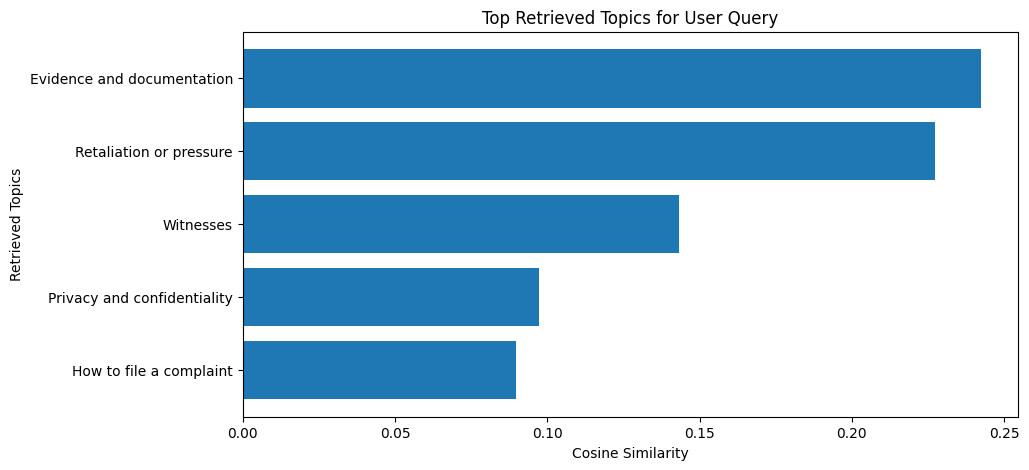

In [22]:
import matplotlib.pyplot as plt

topics = [data[idx]["title"] for idx in top_indices]
scores = [similarities[idx] for idx in top_indices]

plt.figure(figsize=(10, 5))

plt.barh(topics, scores)

plt.xlabel("Cosine Similarity")
plt.ylabel("Retrieved Topics")
plt.title("Top Retrieved Topics for User Query")

plt.gca().invert_yaxis()

plt.show()

## Observations

The retrieval system successfully ranks
evidence-related legal topics higher for
queries involving screenshots and documentation.

This demonstrates that TF-IDF vectorization
combined with cosine similarity can provide
interpretable retrieval behavior for domain-specific
legal information systems.

## Future Improvements

Potential future extensions include:
- Roman Urdu normalization
- multilingual Urdu-English retrieval
- transformer-based embeddings
- semantic search
- contextual ranking
- intent classification
- conversational memory integration

## Conclusion

This notebook demonstrated a lightweight
NLP retrieval pipeline for a legal information
chatbot using TF-IDF vectorization and cosine similarity.

The experiments showed that retrieval-based NLP
methods can support explainable legal information
access systems in socially relevant domains.